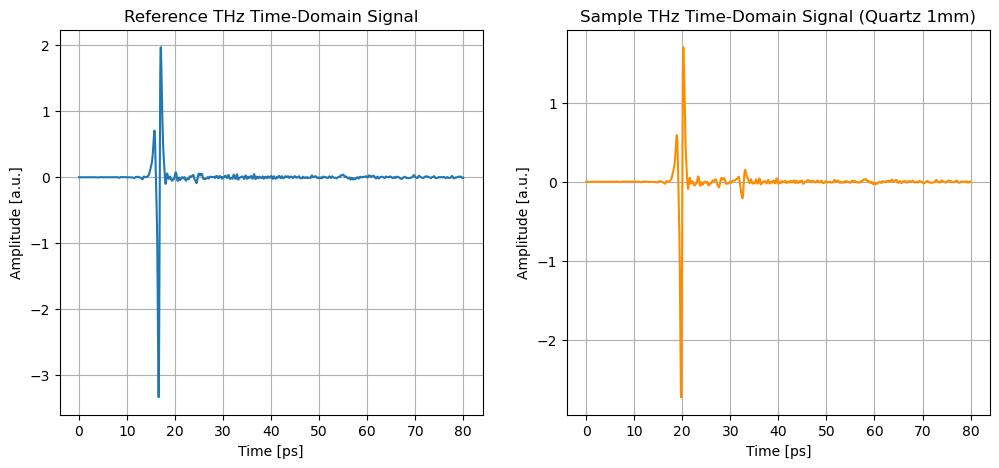

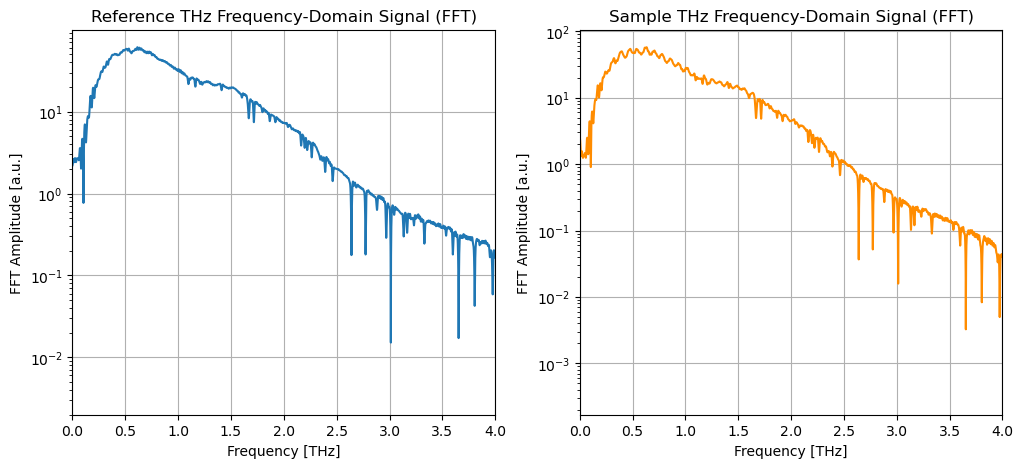

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy import signal


# INSERT REFERENCE DATA 
reference_pulse = np.loadtxt(r"C:\miniconda_projects\repository\TerahertzProject\TheoTHzTDS\THz-TDS\Transfer Matrix Method\data_06_02_2026\reference_15min_2nd_run_nitrogen.txt",dtype=float)

# INSERT SAMPLE DATA
sample_pulse_Quartz = np.loadtxt(r"C:\miniconda_projects\repository\TerahertzProject\TheoTHzTDS\THz-TDS\Transfer Matrix Method\data_06_02_2026\Quartz_1mm_15min_nitrogen.txt",dtype=float)

t1= reference_pulse[:,0] + 740  # ADJUSTING THE AXIS, SO THAT THE SCAN STARTS AT 0 PS.
amp1 = reference_pulse[:,1]
t2 = sample_pulse_Quartz[:,0] + 740  # ADJUSTING THE AXIS
amp2 = sample_pulse_Quartz[:,1]


# FFT OF SIGNALS
reference_fft = np.fft.fft(amp1,65536)  # PERFORM FFT WITH ZERO-PADDING TO 65536 POINTS FOR BETTER FREQUENCY RESOLUTION
sample_fft = np.fft.fft(amp2,65536)

time_step = t1[1] - t1[0]
frequency = np.fft.fftfreq(65536, d=time_step*1e-12)  # CONVERT PS TO S FOR FREQUENCY CALCULATION

# MASK
mask = (frequency > 0) & (frequency < 5 * 1e12) # MASK FREQUENCY RANGE TO FOCUS ON THE 0-5 THZ INTERVAL
reference_fft = reference_fft[mask]
sample_fft = sample_fft[mask]
frequency = frequency[mask]

# PLOTTING REFERENCE AND SAMPLE SIGNALS


# PLOTS
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.plot(t1,amp1)
plt.xlabel('Time [ps]')
plt.ylabel('Amplitude [a.u.]')
plt.title('Reference THz Time-Domain Signal')
plt.grid()  
plt.subplot(1,2,2)
plt.plot(t2,amp2, color='darkorange')
plt.xlabel('Time [ps]')
plt.ylabel('Amplitude [a.u.]')
plt.title('Sample THz Time-Domain Signal (Quartz 1mm)')
plt.grid()
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.plot(frequency*1e-12,np.abs(reference_fft))
plt.xlim(0,4)
plt.yscale('log')
plt.xlabel('Frequency [THz]')
plt.ylabel('FFT Amplitude [a.u.]')
plt.title('Reference THz Frequency-Domain Signal (FFT)')
plt.grid()
plt.subplot(1,2,2)
plt.plot(frequency*1e-12,np.abs(sample_fft), color='darkorange')
plt.xlim(0,4)
plt.yscale('log')
plt.xlabel('Frequency [THz]')
plt.ylabel('FFT Amplitude [a.u.]')
plt.title('Sample THz Frequency-Domain Signal (FFT)')
plt.grid()
plt.show()


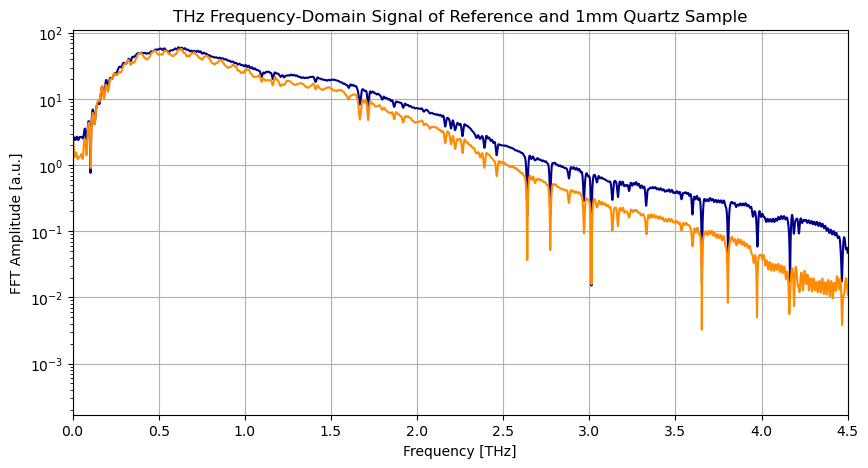

In [2]:
# PLOT FREQUENCY DOMAINS TOGETHER
plt.figure(figsize=(10, 5))
plt.plot(frequency*1e-12,np.abs(reference_fft), label='Reference FFT', color='darkblue')
plt.plot(frequency*1e-12,np.abs(sample_fft), label='Sample FFT (Quartz, d=1mm)', color='darkorange')
plt.xlim(0,4.5)
plt.yscale('log')
plt.xlabel('Frequency [THz]')
plt.ylabel('FFT Amplitude [a.u.]')
plt.grid(True)
plt.title('THz Frequency-Domain Signal of Reference and 1mm Quartz Sample') 
plt.show()

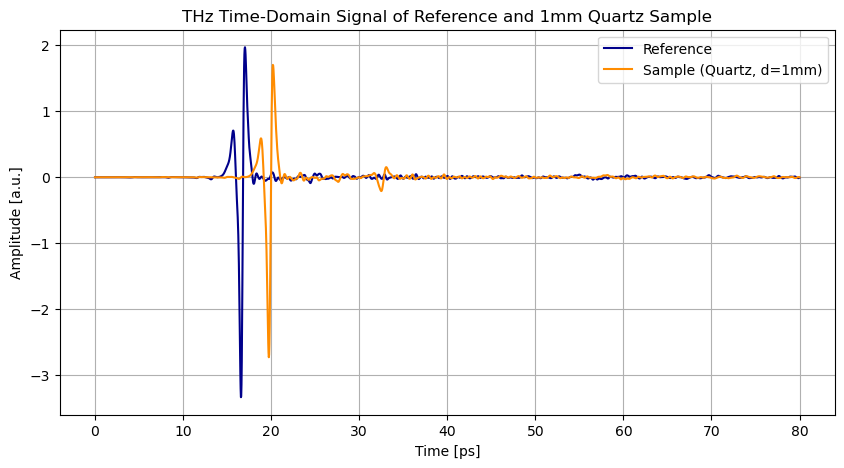

In [3]:
# PLOT THE TIME DOMAIN SIGNALS TOGETHER
plt.figure(figsize=(10, 5))
plt.plot(t1, amp1, label='Reference', color='darkblue')
plt.plot(t2, amp2, label='Sample (Quartz, d=1mm)', color='darkorange')
plt.xlabel('Time [ps]')
plt.ylabel('Amplitude [a.u.]')
plt.title('THz Time-Domain Signal of Reference and 1mm Quartz Sample')
plt.legend()
plt.grid()
plt.show()

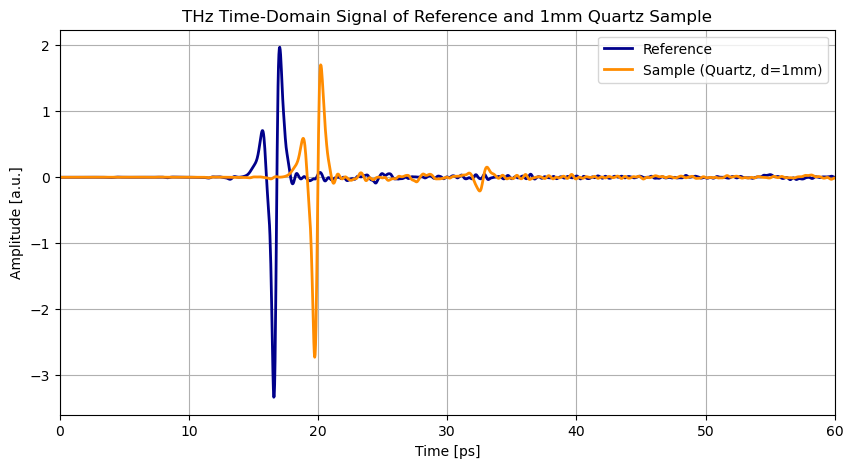

In [4]:
# PLOT THE TIME DOMAIN SIGNALS TOGETHER
plt.figure(figsize=(10, 5))
plt.plot(t1, amp1, label='Reference', color='darkblue',linewidth=2)
plt.plot(t2, amp2, label='Sample (Quartz, d=1mm)', color='darkorange',linewidth=2)
plt.xlabel('Time [ps]')
plt.ylabel('Amplitude [a.u.]')
plt.title('THz Time-Domain Signal of Reference and 1mm Quartz Sample')
plt.xlim(0, 60)  
plt.legend()
plt.grid()
plt.show()

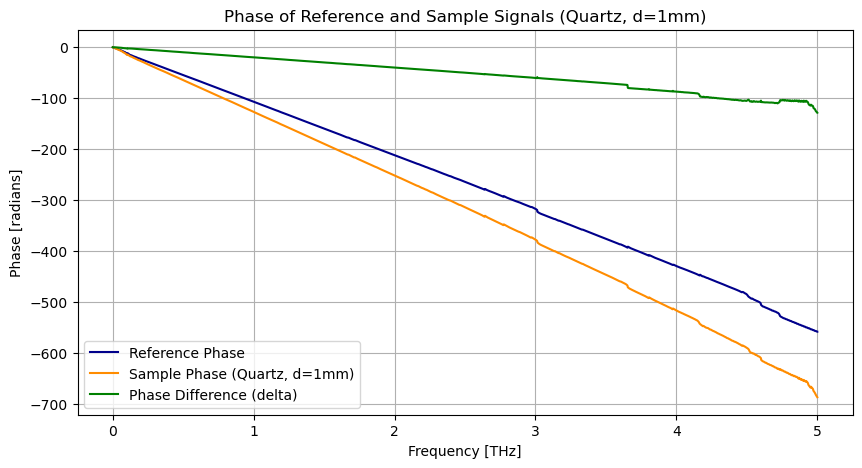

Time delay (ps):  3.1683168299999807


<Figure size 1200x500 with 0 Axes>

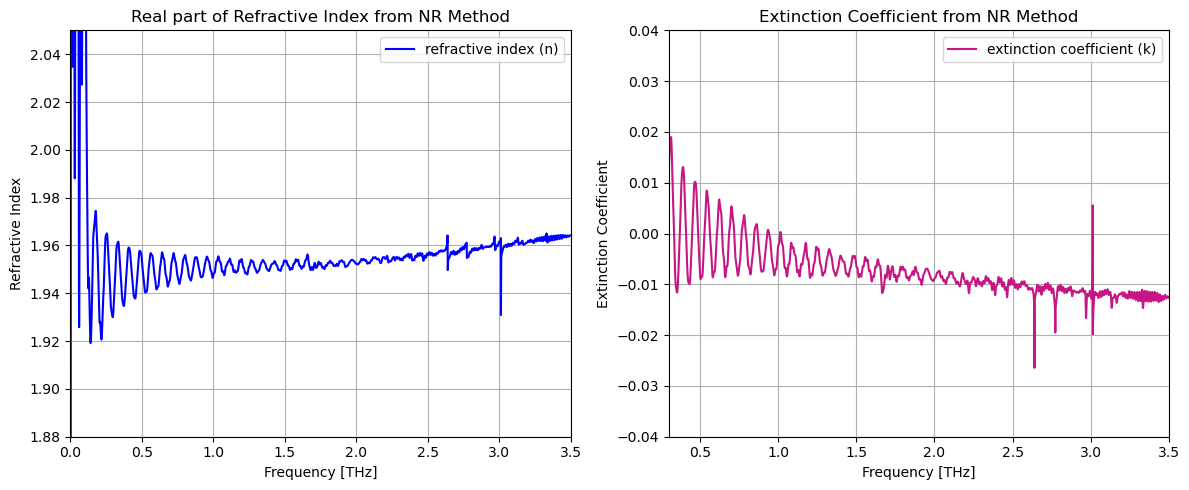

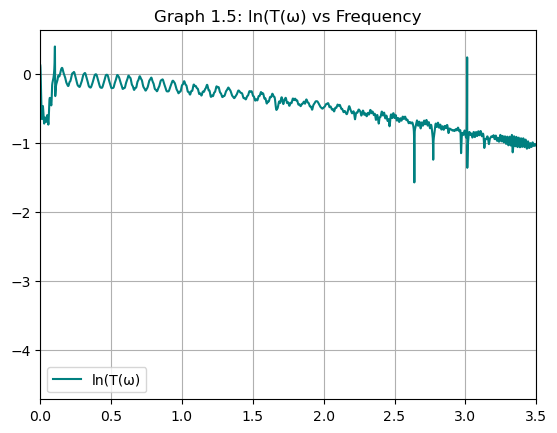

The average value of the real part of the extracted refractive index (n) is: 1.992869435646193
The average value of the imaginary part of the extracted refractive index (k) is: -0.01604026282518772
The theoretical average real refractive index (n_peaks) is: 1.9504950489999942


In [5]:
# PHASE UNWRAPPING 
''' USING THE PHASE UNWRAPPING TO CALCULATE THE UWRAPPED PHASE OF THE REFERENCE AND SAMPLE SIGNALS,
    AND THEN CALCULATING THE PHASE DIFFERENCE (DELTA) BETWEEN THEM. THIS DELTA WILL BE USED LATER TO DEFINE THE 
    THEORETICAL REFRACTIVE INDEX.'''

phase_ref = np.unwrap(np.angle(reference_fft))
phase_sample = np.unwrap(np.angle(sample_fft))
delta = phase_sample - phase_ref

plt.figure(figsize=(10, 5))
plt.plot(frequency*1e-12, phase_ref, label='Reference Phase', color='darkblue')
plt.plot(frequency*1e-12, phase_sample, label='Sample Phase (Quartz, d=1mm)', color='darkorange')
plt.plot(frequency*1e-12, delta, label='Phase Difference (delta)', color='green')
plt.xlabel('Frequency [THz]')
plt.ylabel('Phase [radians]')
plt.title('Phase of Reference and Sample Signals (Quartz, d=1mm)')
plt.legend()
plt.grid()
plt.show()

# TIME DELAY BETWEEN SIGNALS CALCULATION

max_reference_signal = np.max(amp1)
point_in_time_ref = t1[amp1.argmax()]
max_sample_signal = np.max(amp2)
point_in_time_sample = t2[amp2.argmax()]

dt = np.abs(  (point_in_time_sample) -  (point_in_time_ref) ) #time delay in ps
print("Time delay (ps): ", dt)


# INSERT GLOBAL PARAMETERS, LIKE SPEED OF LIGHT, REFRACTIVE INDEX OF AIR, THICKNESS OF SAMPLE, ETC.

frequency[frequency == 0] = 1e-12  # Replace zeros with a small value to avoid division by zero
c = 3e8 #speed of light in m/s
d = 1e-3 #thickness of sample in m
n_0 = 1  # Refractive index of air



# TRANSFER FUNCTION CALCULATION

transfer_signal = sample_fft / reference_fft

transfer_phase = np.angle(sample_fft) - np.angle(reference_fft)
tphase_unwrapped = np.unwrap(transfer_phase)
#tphase_unwrapped -= tphase_unwrapped[0]-0.5*np.pi
ln_transfer = np.log(np.abs(transfer_signal) + 1e-12) + 1j * tphase_unwrapped

# Theoretical refractive index from time delay betweens signal peaks
delta_peaks = point_in_time_sample - point_in_time_ref
delta_peaks_seconds = delta_peaks * 1e-12  # Convert ps to seconds
n_peaks = c * delta_peaks_seconds / d + n_0

refractive = 1 + (np.abs(delta)* c) / (2 * np.pi * frequency * d)

# NEWTON RAPHSON METHOD
def G_zero(n, f, ln_exp):

    ln_th =(np.log((4 * n_0 * n) / (n_0 + n)**2)
             -(1j * 2 * np.pi * f * d / c) * (n - n_0))
    return  ln_th - ln_exp

def G_zerod(n, f):
    p = 1 / n
    m = 2 / (n + n_0) + (1j * 2 * np.pi* f * d) / c 
    return p - m 

def new_raph(n_1, ln_exp, f, iterations, tol):
    n = n_1
    for i in range(iterations): 
        G_zero_ = G_zero(n,  f, ln_exp)
        G_zerod_ = G_zerod(n, f)
        dn = G_zero_ / G_zerod_
        n = n - dn
        if abs(G_zero_/G_zerod_) < tol:
           # print(i, "iterations")
            break
    return n


# INITIAL GUESS AND CALCULATION
n_1 = 2.1 + 0.01j
n_ = []

for i, f in enumerate(frequency, 0):
    ln_exp = np.log(np.abs(transfer_signal[i])) + 1j * tphase_unwrapped[i]
    n_values = new_raph( n_1 ,ln_exp, f,  iterations=70, tol=1e-10)
    n_.append(n_values)


# print("Refractive index values:", n_)
n_ = np.array(n_) 


# PLOTTING REFRACTIVE INDEX AND TRANSFER FUNCTION

plt.figure(figsize=(12,5))

# REFRACTIVE INDICES REAL PART
'''plt.subplot(1,2,1)
plt.plot(frequency*1e-12, refractive, label='Refractive Index [theoretical]', color='orange')
plt.xlim(xmax = 3.5, xmin = 0)
plt.ylim(ymin=0, ymax=3.2)
plt.legend(["refractive index n_th"])
plt.grid(True)
plt.title('Graph 1.3: Theoretical Refractive Index') '''

plt.figure(figsize=(12, 5))
# REFRACTIVE INDEX
plt.subplot(1,2,1)
plt.plot(frequency*1e-12, n_.real, label='Refractive Index [n]', color='blue')
plt.xlim(xmax =3.5, xmin = 0)
plt.ylim(ymin=1.88, ymax=2.05)
plt.legend(["refractive index (n)"])
plt.grid(True)
plt.title('Real part of Refractive Index from NR Method')
plt.xlabel('Frequency [THz]')
plt.ylabel('Refractive Index')

# EXTINCTION COEFFICIENT
plt.subplot(1,2,2)
plt.plot(frequency*1e-12, n_.imag, label='Extinction Coefficient (k)', color='mediumvioletred')
plt.xlim(xmax = 3.5, xmin = 0.3)
plt.ylim(ymin=-0.04, ymax=0.04)
plt.legend(["extinction coefficient (k)"])
plt.title('Extinction Coefficient from NR Method')
plt.xlabel('Frequency [THz]')
plt.ylabel('Extinction Coefficient')
plt.grid(True)
plt.tight_layout()
plt.show()

# NATURAL LOGARITHM OF THE TRANSFER FUNCTION
plt.plot(frequency*1e-12, np.log(np.abs(transfer_signal)), label='Transfer Function Amplitude', color='teal')
plt.xlim(0,3.5)
plt.legend(["ln(T(ω)"])
plt.title('Graph 1.5: ln(T(ω) vs Frequency')
plt.grid(True)
plt.show()  


print(f"The average value of the real part of the extracted refractive index (n) is: {np.mean(n_.real)}")
print(f"The average value of the imaginary part of the extracted refractive index (k) is: {np.mean(n_.imag)}")   
print(f"The theoretical average real refractive index (n_peaks) is: {np.mean(n_peaks)}")


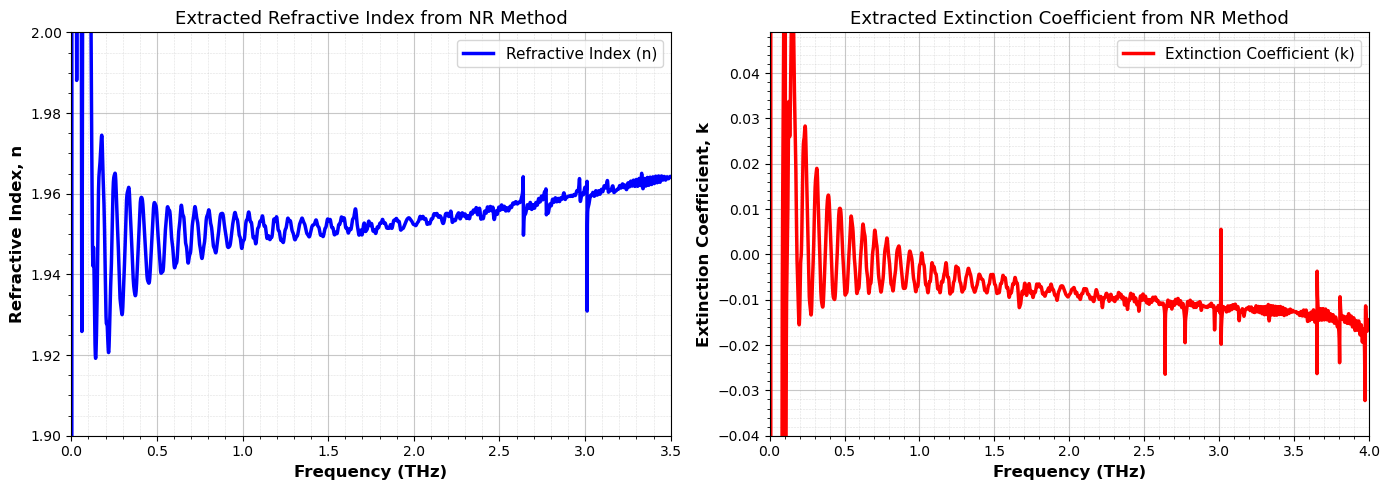

In [6]:
# PLOT OF THE EXTRACTED REFRACTIVE INDEX FROM NR METHOD (REAL AND IMAGINARY PARTS)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left subplot: Refractive Index (Real part)
axes[0].plot(frequency*1e-12, n_.real, label='Refractive Index (n)', color='blue', linewidth=2.5)
axes[0].set_xlabel('Frequency (THz)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Refractive Index, n', fontsize=12, fontweight='bold')
axes[0].set_title('Extracted Refractive Index from NR Method', fontsize=13)
axes[0].set_xlim(0.0, 3.5)
axes[0].set_ylim(1.9, 2.0)
axes[0].grid(True, which='major', linestyle='-', linewidth=0.8, alpha=0.7)
axes[0].grid(True, which='minor', linestyle='--', linewidth=0.4, alpha=0.4)
axes[0].minorticks_on()
axes[0].legend(fontsize=11, loc='best')

# Right subplot: Extinction Coefficient (Imaginary part)
axes[1].plot(frequency*1e-12, n_.imag, label='Extinction Coefficient (k)', color='red', linewidth=2.5)
axes[1].set_xlabel('Frequency (THz)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Extinction Coefficient, k', fontsize=12, fontweight='bold')
axes[1].set_title('Extracted Extinction Coefficient from NR Method', fontsize=13)
axes[1].set_xlim(0.0, 4.0)
axes[1].set_ylim(-0.04, 0.049)
axes[1].grid(True, which='major', linestyle='-', linewidth=0.8, alpha=0.7)
axes[1].grid(True, which='minor', linestyle='--', linewidth=0.4, alpha=0.4)
axes[1].minorticks_on()
axes[1].legend(fontsize=11, loc='best')

plt.tight_layout()
plt.show()

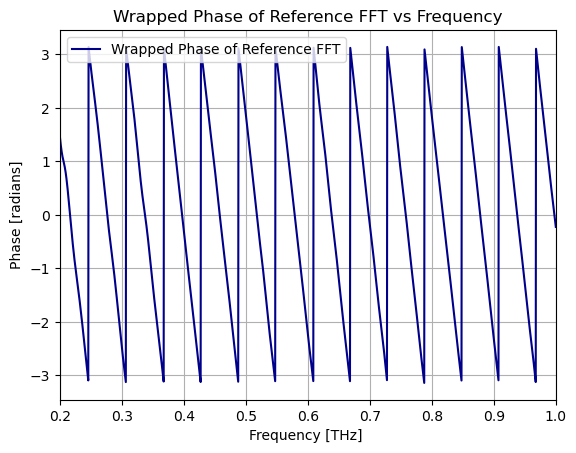

In [7]:
phi_ref = np.angle(reference_fft)
phi_sam = np.angle(sample_fft)
plt.plot(frequency*1e-12, phi_ref, label='Phase of Reference FFT', color='darkblue')
#plt.plot(frequency*1e-12, phi_sam, label='Phase of Sample FFT (Quartz, d=1mm)', color='darkorange')
plt.xlim(xmax = 1, xmin = 0.2)
plt.legend(["Wrapped Phase of Reference FFT"], loc='upper left')
plt.ylabel('Phase [radians]')
plt.xlabel('Frequency [THz] ') 
plt.title('Wrapped Phase of Reference FFT vs Frequency')
plt.grid(True)
plt.show()

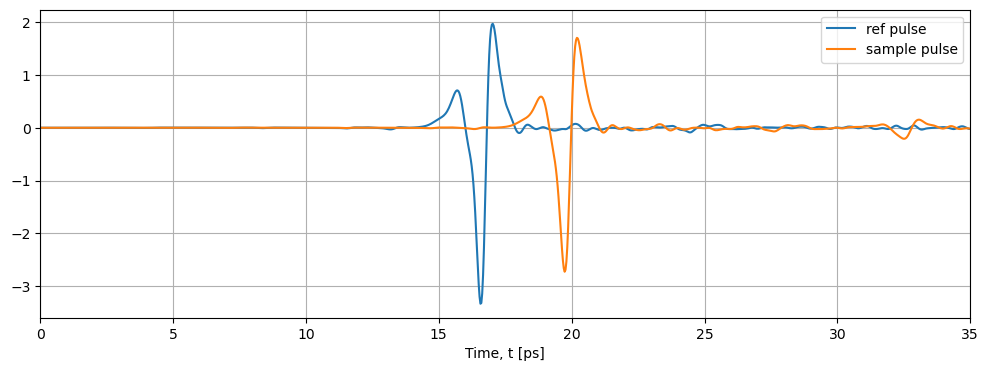

In [8]:
import torch
from Matrix_methods.BayesianExtractor import BayesianLayeredExtractor
from Matrix_methods.AdamExtractor import LayeredExtractor
from Matrix_methods.Simulate import simulate_parallel

# BAYES AND ADAM EXTRACTION

# CONVERT DATA TO TENSORS

# REFERENCE PULSE
reference_pulse_tensor = torch.tensor(amp1, dtype=torch.float32)
#SAMPLE PULSE
sample_pulse_tensor = torch.tensor(amp2, dtype=torch.float32)


plt.figure(figsize=(12,4))
plt.plot(t1, reference_pulse_tensor.detach().cpu().numpy(),label='ref pulse')
plt.plot(t2, sample_pulse_tensor.detach().cpu().numpy(),label='sample pulse')
plt.xlabel('Time, t [ps]')
plt.legend()
plt.xlim(0,35)
plt.grid()
plt.show()

Delta t:  3.30033000000185e-14
Number of time points, L:  2425
Starting Bayesian Optimization with masks...
Search Boundaries for Optimized Parameters:
Layer 1 - n ∈ (1.692, 2.292)
Layer 1 - k ∈ (-0.026000000000000002, -0.006)
Layer 1 - D ∈ (0.00098, 0.00102)


[((1.9694516733691396-0.006j), 0.00098)]


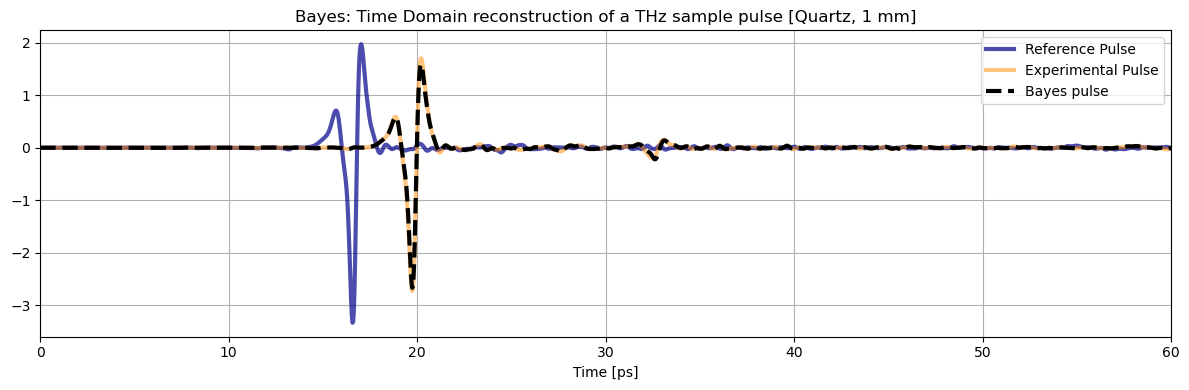

Fine-tuning 3 parameters for 2000 iterations.
Iteration 49, Loss: 1.213230e-02, Layer 0: n=1.9715, k=-0.00401, D=977.28 µm
Iteration 99, Loss: 1.145123e-02, Layer 0: n=1.9747, k=-0.00398, D=974.19 µm
Iteration 149, Loss: 1.103646e-02, Layer 0: n=1.9775, k=-0.00394, D=971.54 µm
Iteration 199, Loss: 1.084969e-02, Layer 0: n=1.9796, k=-0.00393, D=969.63 µm
Iteration 249, Loss: 1.078507e-02, Layer 0: n=1.9808, k=-0.00392, D=968.42 µm
Iteration 299, Loss: 1.076741e-02, Layer 0: n=1.9816, k=-0.00392, D=967.76 µm
Iteration 349, Loss: 1.076351e-02, Layer 0: n=1.9819, k=-0.00392, D=967.43 µm
Iteration 399, Loss: 1.076282e-02, Layer 0: n=1.9821, k=-0.00392, D=967.29 µm
Iteration 449, Loss: 1.076271e-02, Layer 0: n=1.9821, k=-0.00392, D=967.23 µm
Iteration 499, Loss: 1.076269e-02, Layer 0: n=1.9821, k=-0.00392, D=967.21 µm
Iteration 549, Loss: 1.076270e-02, Layer 0: n=1.9822, k=-0.00392, D=967.20 µm
Iteration 599, Loss: 1.076270e-02, Layer 0: n=1.9822, k=-0.00392, D=967.20 µm
Iteration 649, Loss:

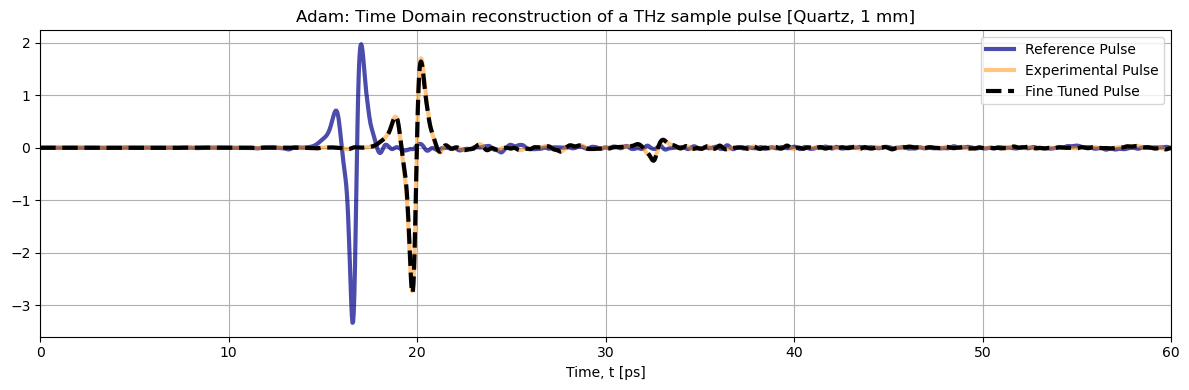

In [9]:
# set initial guesses for Bayes optimization
layers_init = [(1.992-0.016j, 1e-3)] 
# set bounds for optimization
optimization_bounds = [0.3, 0.01, 0.20e-4]

deltat = t1[1] - t1[0]
deltat = deltat * 1e-12
L = len(reference_pulse)


print("Delta t: ", deltat)
print("Number of time points, L: ", L)

# Set optimization mask
optimization_mask = [(True, True, True),]


# Initialize extractor for the data
Bayes_extractor = BayesianLayeredExtractor(reference_pulse_tensor,sample_pulse_tensor, deltat, layers_init,optimization_bounds=optimization_bounds,optimize_mask=optimization_mask)

# Run the extraction loop and returns parameters
bayes_params = ms = Bayes_extractor.bayesian_optimization(n_calls=50)




# Run forward pass with Jeff’s model
bayes_pulse = simulate_parallel(reference_pulse_tensor,bayes_params, deltat, noise_level=0)[1].detach().cpu().numpy()[:L]

 # Print the parameters
print(bayes_params)

 # plot the pulse
plt.figure(figsize=(12,4))
plt.plot(t1, reference_pulse_tensor.detach().cpu().numpy(), label='Reference Pulse', alpha=0.7,linewidth=3,color='darkblue')
plt.plot(t2, sample_pulse_tensor.detach().cpu().numpy(), label='Experimental Pulse', alpha=0.5,linewidth=3,color='darkorange')
plt.plot(t1, bayes_pulse, label='Bayes pulse', linestyle='--', linewidth=3, color='black')
plt.xlabel('Time [ps]')
plt.xlim(0,60)
plt.grid(True)
plt.title('Bayes: Time Domain reconstruction of a THz sample pulse [Quartz, 1 mm]')
plt.tight_layout()
plt.legend()
plt.show()







 # Initialize adam optimizer object
grad_optimizer = LayeredExtractor(reference_pulse_tensor,sample_pulse_tensor, deltat, bayes_params,optimization_mask, lr=0.0001)
 # Run optimization for set iterations, ‘updates’ provides a printout of progress
optim_params = grad_optimizer.optimize(num_iterations=2000,updates=50)
optim_pulse = simulate_parallel(reference_pulse_tensor,
optim_params, deltat, 0)[1].detach().cpu().numpy()[:L]
print(optim_params)
plt.figure(figsize=(12,4))
plt.plot(t1, reference_pulse_tensor.detach().cpu().numpy(), label='Reference Pulse',
alpha=0.7,linewidth=3,color='darkblue')
plt.plot(t2, sample_pulse_tensor.detach().cpu().numpy(),
label='Experimental Pulse',alpha=0.5,linewidth=3,color='darkorange')
plt.plot(t1, optim_pulse, label='Fine Tuned Pulse',alpha=1, linestyle='--',linewidth=3,color='black')
plt.xlim(0,60)
plt.xlabel('Time, t [ps]')
plt.title('Adam: Time Domain reconstruction of a THz sample pulse [Quartz, 1 mm]')
plt.legend() 
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
bayes_params

[((1.9694516733691396-0.006j), 0.00098)]

In [11]:
optim_params

[((1.9821455478668213-0.003920860588550568j), 0.0009672068408690393)]

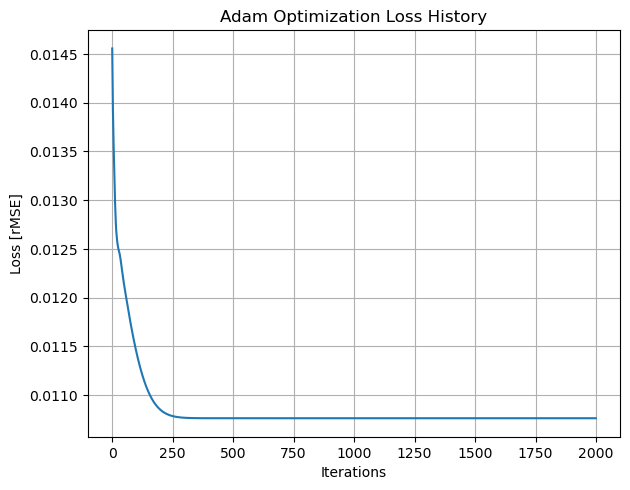

In [12]:
plt.plot(grad_optimizer.loss_history)
plt.xlabel('Iterations')
plt.ylabel('Loss [rMSE]')
plt.grid(True)
plt.tight_layout()
plt.title('Adam Optimization Loss History')
plt.show()

In [13]:
min_loss = min(grad_optimizer.loss_history)

In [14]:
final_loss = grad_optimizer.loss_history[-1]

In [15]:
abs(min_loss - final_loss)/abs(min_loss) *100

0.00013845210374943006

In [ ]:
'''from loss_landscape_visualization import LossLandscapeVisualizer
from Matrix_methods.AdamExtractor import gen_loss_function
from Matrix_methods.AdamExtractor import simulate_parallel

extractor = BayesianLayeredExtractor(reference_pulse_tensor, 
                                     sample_pulse_tensor, 
                                     deltat=deltat, 
                                     layers_init = layers_init, 
                                     optimize_mask=[(True, True, True)], 
                                     optimization_bounds=[0.175, 0.001, 23e-6])

bayesian_best_layers= extractor.bayesian_optimization(n_calls=50)

n_complex_bays, D_bays = bayesian_best_layers[0]
n_bays = n_complex_bays.real
k_bays = n_complex_bays.imag

adam_extractor = LayeredExtractor(reference_pulse_tensor,
                                 sample_pulse_tensor,
                                 deltat=deltat,
                                 layers_init=layers_init,
                                 optimize_mask=optimization_mask)

adam_best_layers = adam_extractor.optimize(num_iterations=700, verbose=True, updates=100, alpha=1)

n_complex_adam, D_adam = adam_best_layers[0]
n_adam = n_complex_adam.real
k_adam = n_complex_adam.imag


# GENERATE LOSS FUNCTION
def loss_func(params):
    n = params.get('n', (n_bays + n_adam)/2)
    k = params.get('k', (k_bays + k_adam)/2)
    d = params.get('d', (D_bays + D_adam)/2)
    layers = [(n + 1j * k, d)]
    T, y_sim = simulate_parallel(reference_pulse_tensor, layers, deltat)
    y_sim = y_sim[:len(sample_pulse_tensor)]  # Truncate to match sample length
    loss = gen_loss_function(y_sim, sample_pulse_tensor, alpha=1)
    return loss.item()


param_ranges = {
    'n': (1.2, 2.6),
    'k': (-0.02, 0.01),
    'd': (0.4e-3, 1.5e-3)
}

visualizer = LossLandscapeVisualizer(loss_func, param_ranges,cmap='magma')

final_values = {
    'Bayesian': {'n': float(n_bays), 'k': float(k_bays), 'd': float(D_bays)},
    'ADAM': {'n': float(n_adam), 'k': float(k_adam), 'd': float(D_adam)}
}
'''



ModuleNotFoundError: No module named 'loss_landscape_visualization'

In [ ]:
'''
#Plotting loss landscape
# 1D slices
visualizer.plot_1d_slices(optimizer_values=final_values)
plt.show()

# 2D landscape n vs k 
bays_path = [(p['n'][0], abs(p['k'][0])) for p in extractor.iteration_history]
adam_path = [(p['n'][0], abs(p['k'][0])) for p in adam_extractor.iteration_history]

optimzer_path = {
        'ADAM': adam_path,
        'Bayesian': bays_path
    }

# Find d at minimum loss on the 1D slice
p_min, p_max = param_ranges['d']
d_vals = np.linspace(p_min, p_max, 100)

# Use the same fixed params as the 1D slice (midpoint of n and k ranges)
fixed_nk = {
    'n': (param_ranges['n'][0] + param_ranges['n'][1]) / 2,
    'k': (param_ranges['k'][0] + param_ranges['k'][1]) / 2,
}

d_losses = [loss_func({**fixed_nk, 'd': d}) for d in d_vals]
d_fixed = float(d_vals[np.argmin(d_losses)])


visualizer.plot_2d_slice('n', 'k', 
                  fixed_params={'d': d_fixed},
                  optimizer_paths=optimzer_path,
                  resolution=40)
plt.show()

'''



"\n#Plotting loss landscape\n# 1D slices\nvisualizer.plot_1d_slices(optimizer_values=final_values)\nplt.show()\n\n# 2D landscape n vs k \nbays_path = [(p['n'][0], abs(p['k'][0])) for p in extractor.iteration_history]\nadam_path = [(p['n'][0], abs(p['k'][0])) for p in adam_extractor.iteration_history]\n\noptimzer_path = {\n        'ADAM': adam_path,\n        'Bayesian': bays_path\n    }\n\n# Find d at minimum loss on the 1D slice\np_min, p_max = param_ranges['d']\nd_vals = np.linspace(p_min, p_max, 100)\n\n# Use the same fixed params as the 1D slice (midpoint of n and k ranges)\nfixed_nk = {\n    'n': (param_ranges['n'][0] + param_ranges['n'][1]) / 2,\n    'k': (param_ranges['k'][0] + param_ranges['k'][1]) / 2,\n}\n\nd_losses = [loss_func({**fixed_nk, 'd': d}) for d in d_vals]\nd_fixed = float(d_vals[np.argmin(d_losses)])\n\n\nvisualizer.plot_2d_slice('n', 'k', \n                  fixed_params={'d': d_fixed},\n                  optimizer_paths=optimzer_path,\n                  resolutio

In [ ]:
'''
#Zoom in on optimizer path of ADAM
adam_n = [adam_path[i][0] for i in range(len(adam_path))]
adam_k = [adam_path[i][1] for i in range(len(adam_path))]

plt.plot(adam_n, adam_k, '-', label='ADAM Path')
plt.title('Adam optimisation path in n-k space')
plt.xlabel('n')
plt.ylabel('k')
plt.grid()
plt.show()

'''

"\n#Zoom in on optimizer path of ADAM\nadam_n = [adam_path[i][0] for i in range(len(adam_path))]\nadam_k = [adam_path[i][1] for i in range(len(adam_path))]\n\nplt.plot(adam_n, adam_k, '-', label='ADAM Path')\nplt.title('Adam optimisation path in n-k space')\nplt.xlabel('n')\nplt.ylabel('k')\nplt.grid()\nplt.show()\n\n"

In [ ]:
'''
#Optimizer convergence
optimizer_histories = {
    'Bayesian': extractor.loss_history,
    'ADAM': adam_extractor.loss_history
}

fig3, _ = visualizer.plot_convergence_comparison(optimizer_histories)
plt.show()
'''

"\n#Optimizer convergence\noptimizer_histories = {\n    'Bayesian': extractor.loss_history,\n    'ADAM': adam_extractor.loss_history\n}\n\nfig3, _ = visualizer.plot_convergence_comparison(optimizer_histories)\nplt.show()\n"

In [ ]:
#Printing the results
print("-------------------------------- RESULTS --------------------------------")
print("Initital values:")
print("layer 1: n = 2, k = 0.01, d = 1e-3")
print()
print("Bayesian Optimization Results: n =", np.round(n_bays, 3), "k =", np.round(k_bays, 5), "d =", np.round(D_bays, 6))
print()
print("Adam Optimization Results: n =", np.round(n_adam, 3), "k =", np.round(k_adam, 5), "d =", np.round(D_adam, 6))
print("------------------------------------------------------------------------")   

-------------------------------- RESULTS --------------------------------
Initital values:
layer 1: n = 2, k = 0.01, d = 1e-3

Bayesian Optimization Results: n = 1.972 k = -0.015 d = 0.000977

Adam Optimization Results: n = 1.982 k = -0.00392 d = 0.000967
------------------------------------------------------------------------


In [ ]:
# Local minima test
visualizer.analyze_local_minima(final_values, n_samples=2000)



LOCAL MINIMA ANALYSIS

Bayesian:
  Loss at solution: 3.549473e-02
  Random samples with lower loss: 8/2000 (0.4%)
  Min loss in samples: 2.465635e-02
  Mean loss in samples: 2.462607e-01
Appears to be near global minimum

ADAM:
  Loss at solution: 1.076270e-02
  Random samples with lower loss: 0/2000 (0.0%)
  Min loss in samples: 1.515965e-02
  Mean loss in samples: 2.645020e-01
Appears to be near global minimum



{'Bayesian': {'optimizer_loss': 0.03549472615122795,
  'samples_with_lower_loss': 8,
  'percentage': 0.4,
  'min_sample_loss': 0.024656346067786217,
  'mean_sample_loss': np.float64(0.24626068843901158)},
 'ADAM': {'optimizer_loss': 0.010762699879705906,
  'samples_with_lower_loss': 0,
  'percentage': 0.0,
  'min_sample_loss': 0.01515964511781931,
  'mean_sample_loss': np.float64(0.26450196089642125)}}

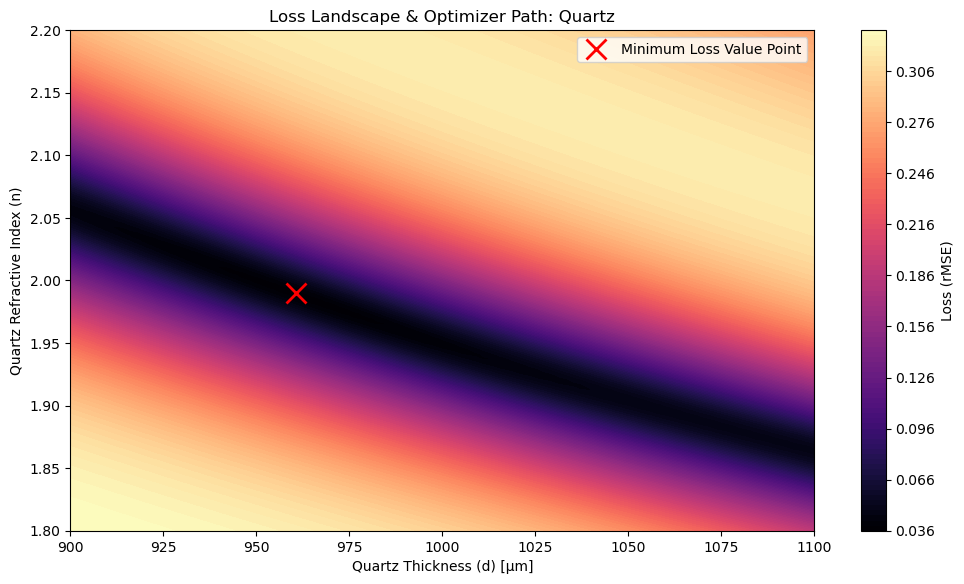

<Figure size 640x480 with 0 Axes>

In [ ]:
from Matrix_methods.Loss_Structured_Grid_Visualization import generate_landscape_grid,plot_grid_landscape
adam_history = grad_optimizer.iteration_history
bayes_history = extractor.iteration_history

n_d_Q = { (0, 'n'): (1.8, 2.2), (0, 'd'): (900e-6, 1100e-6) }
data, a1, a2, keys = generate_landscape_grid(reference_pulse_tensor, sample_pulse_tensor, deltat, layers_init , n_d_Q , num_points=100)
plot_grid_landscape(data, a1, a2,keys)